# **Preprocessing**

**Step 1: Import libraries**

In [1]:
# Core libraries for file handling, arrays, and dataframes.
import os
import cv2
import numpy as np
import pandas as pd

# Progress bar.
from tqdm import tqdm

# PyTorch libraries.
import torch
from torch.utils.data import Dataset, DataLoader

**Step 2: Face Detection and Cropping**

In [2]:
# Load OpenCV Haar Cascade model for frontal face detection.
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# This function detects the largest face in a frame and crops it.
def detect_and_crop_face(frame, margin=0.35):
    # Convert the frame to grayscale because Haar Cascade works on gray images.
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect faces in the frame.
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

    # If at least one face is found, crop the largest detected face.
    if len(faces) > 0:
        # Select the biggest face because it is most likely the main face in the video.
        x, y, w, h = max(faces, key=lambda box: box[2] * box[3])

        # Add a margin around the face so important facial areas are not cut off.
        margin_x = int(w * margin)
        margin_y = int(h * margin)

        # Keep the crop coordinates inside the frame boundaries.
        x1 = max(0, x - margin_x)
        y1 = max(0, y - margin_y)
        x2 = min(frame.shape[1], x + w + margin_x)
        y2 = min(frame.shape[0], y + h + margin_y)

        # Return the cropped face region.
        return frame[y1:y2, x1:x2]

    # If no face is detected, return the original frame instead.
    return frame

**Step 3: Set paths**

In [3]:
# Store the main DAiSEE dataset path from Kaggle.
base_path = "/kaggle/input/datasets/olgaparfenova/daisee/DAiSEE"

# Create paths for the video folders and label files.
dataset_path = os.path.join(base_path, "DataSet")
labels_path = os.path.join(base_path, "Labels")

# Create paths for the train, validation, and test video folders.
train_path = os.path.join(dataset_path, "Train")
val_path = os.path.join(dataset_path, "Validation")
test_path = os.path.join(dataset_path, "Test")

# Create paths for the train, validation, and test label CSV files.
train_labels_path = os.path.join(labels_path, "TrainLabels.csv")
val_labels_path = os.path.join(labels_path, "ValidationLabels.csv")
test_labels_path = os.path.join(labels_path, "TestLabels.csv")

**Step 4: Load labels**

In [4]:
# Read the label CSV files into pandas dataframes.
train_labels = pd.read_csv(train_labels_path)
val_labels = pd.read_csv(val_labels_path)
test_labels = pd.read_csv(test_labels_path)

**Step 5: Clean column names**

In [5]:
# Remove extra spaces from column names to avoid errors when selecting columns.
train_labels.columns = train_labels.columns.str.strip()
val_labels.columns = val_labels.columns.str.strip()
test_labels.columns = test_labels.columns.str.strip()

**Step 6: Keep only ClipID and Frustration**

In [6]:
# Keep only the video ID column and the Frustration label column.
train_labels = train_labels[[train_labels.columns[0], "Frustration"]].copy()
val_labels = val_labels[[val_labels.columns[0], "Frustration"]].copy()
test_labels = test_labels[[test_labels.columns[0], "Frustration"]].copy()

# Rename the selected columns to clear and consistent names.
train_labels.columns = ["ClipID", "Frustration"]
val_labels.columns = ["ClipID", "Frustration"]
test_labels.columns = ["ClipID", "Frustration"]

**Step 7: Convert to binary stress label**

In [7]:
# Convert the original frustration score into a binary stress label.
def to_binary_stress(x):
    # Scores 0 and 1 are treated as no stress, while 2 and 3 are treated as stress.
    return 0 if x in [0, 1] else 1

# Apply the binary conversion to each dataset split.
train_labels["StressLabel"] = train_labels["Frustration"].apply(to_binary_stress)
val_labels["StressLabel"] = val_labels["Frustration"].apply(to_binary_stress)
test_labels["StressLabel"] = test_labels["Frustration"].apply(to_binary_stress)

# Display the first rows and check the class distribution.
print(train_labels.head())
print(train_labels["StressLabel"].value_counts())

           ClipID  Frustration  StressLabel
0  1100011002.avi            0            0
1  1100011003.avi            0            0
2  1100011004.avi            0            0
3  1100011005.avi            0            0
4  1100011006.avi            0            0
StressLabel
0    5124
1     234
Name: count, dtype: int64


**Step 8: Build dataframe of video paths and labels**

In [8]:
# This function connects each video file with its matching binary label.
def build_dataframe(video_path, labels_df):
    # Store video paths and labels here.
    data = []

    # Walk through all folders inside the selected video split.
    for root, dirs, files in os.walk(video_path):
        for file in files:
            # Keep only video files.
            if file.endswith(".avi") or file.endswith(".mp4"):
                # Find the row in the labels file that matches the video filename.
                row = labels_df[labels_df["ClipID"] == file]

                # Add the video path and label only if the video has a label.
                if not row.empty:
                    label = row["StressLabel"].values[0]
                    full_path = os.path.join(root, file)
                    data.append([full_path, label])

    # Return a dataframe with two columns: video path and label.
    return pd.DataFrame(data, columns=["video_path", "label"])

In [9]:
# Build dataframes for train, validation, and test videos.
train_df = build_dataframe(train_path, train_labels)
val_df = build_dataframe(val_path, val_labels)
test_df = build_dataframe(test_path, test_labels)

# Print the number of matched videos in each split.
print("Train videos:", len(train_df))
print("Validation videos:", len(val_df))
print("Test videos:", len(test_df))

# Display sample rows to confirm that paths and labels were created correctly.
print(train_df.head())

Train videos: 5358
Validation videos: 1429
Test videos: 1784
                                          video_path  label
0  /kaggle/input/datasets/olgaparfenova/daisee/DA...      0
1  /kaggle/input/datasets/olgaparfenova/daisee/DA...      0
2  /kaggle/input/datasets/olgaparfenova/daisee/DA...      0
3  /kaggle/input/datasets/olgaparfenova/daisee/DA...      0
4  /kaggle/input/datasets/olgaparfenova/daisee/DA...      0


**Step 9: Extract frame sequences**

In [10]:
# This function extracts a fixed number of frames from each video.
def extract_sequence(df, num_frames=10, img_size=224):
    # Store extracted frame sequences and their labels.
    data = []

    # Loop through each video path in the dataframe.
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        video_path = row["video_path"]
        label = row["label"]

        # Open the video file using OpenCV.
        cap = cv2.VideoCapture(video_path)
        frames = []

        # Get the total number of frames and calculate the sampling step.
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        step = max(1, total_frames // num_frames)

        # Read frames evenly from the video until the required number is reached.
        count = 0
        while len(frames) < num_frames:
            cap.set(cv2.CAP_PROP_POS_FRAMES, count)
            ret, frame = cap.read()

            # Stop if the video cannot provide more frames.
            if not ret:
                break

            # Crop the face area if detected.
            frame = detect_and_crop_face(frame)

            # Resize the frame to match the CNN input size.
            frame = cv2.resize(frame, (img_size, img_size))

            # Convert from BGR to RGB because deep learning models usually expect RGB images.
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            # Add the processed frame to the sequence.
            frames.append(frame)
            count += step

        # Close the video file after reading.
        cap.release()

        # Keep only videos that produced the full required sequence length.
        if len(frames) == num_frames:
            data.append([frames, label])

    # Return all valid frame sequences with their labels.
    return data

**Step 10: Balanced sampling**

In [11]:
# Take a balanced sample from each class in the training set.
train_sample = train_df.groupby("label", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 300), random_state=42)
).reset_index(drop=True)

# Take a balanced sample from each class in the validation set.
val_sample = val_df.groupby("label", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 80), random_state=42)
).reset_index(drop=True)

# Take a balanced sample from each class in the test set.
test_sample = test_df.groupby("label", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 80), random_state=42)
).reset_index(drop=True)

# Print class counts to confirm that the samples are balanced.
print("Train sample:")
print(train_sample["label"].value_counts())

print("Validation sample:")
print(val_sample["label"].value_counts())

print("Test sample:")
print(test_sample["label"].value_counts())

Train sample:
label
0    300
1    234
Name: count, dtype: int64
Validation sample:
label
0    80
1    80
Name: count, dtype: int64
Test sample:
label
0    80
1    80
Name: count, dtype: int64


/tmp/ipykernel_57/2513080125.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_sample = train_df.groupby("label", group_keys=False).apply(
/tmp/ipykernel_57/2513080125.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  val_sample = val_df.groupby("label", group_keys=False).apply(
/tmp/ipykernel_57/2513080125.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprec

**Step 11: Create sequences**

In [12]:
# Extract frame sequences from the balanced training sample.
train_seq = extract_sequence(train_sample, num_frames=10, img_size=224)

# Extract frame sequences from the balanced validation sample.
val_seq = extract_sequence(val_sample, num_frames=10, img_size=224)

# Extract frame sequences from the balanced test sample.
test_seq = extract_sequence(test_sample, num_frames=10, img_size=224)

# Print the number of valid sequences created for each split.
print("Train sequences:", len(train_seq))
print("Validation sequences:", len(val_seq))
print("Test sequences:", len(test_seq))

100%|██████████| 160/160 [01:55<00:00,  1.39it/s]

Train sequences: 534
Validation sequences: 160
Test sequences: 160


**Step 12: Dataset class**

In [13]:
# Create a custom PyTorch dataset for video frame sequences.
class VideoDataset(Dataset):
    def __init__(self, data):
        # Store the extracted sequences and labels.
        self.data = data

        # ImageNet mean and standard deviation used to normalize RGB frames.
        self.mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        self.std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    # Return the number of samples in the dataset.
    def __len__(self):
        return len(self.data)

    # Load one sample by index.
    def __getitem__(self, idx):
        frames, label = self.data[idx]

        # Convert pixel values from 0-255 to 0-1.
        frames = np.array(frames, dtype=np.float32) / 255.0

        # Normalize frames using ImageNet statistics.
        frames = (frames - self.mean) / self.std

        # Convert frames to a PyTorch tensor.
        frames = torch.tensor(frames, dtype=torch.float32)

        # Change shape from (T, H, W, C) to (T, C, H, W) for CNN input.
        frames = frames.permute(0, 3, 1, 2)  

        # Return the frames and label as tensors.
        return frames, torch.tensor(label, dtype=torch.long)

**Step 13: DataLoaders**

In [14]:
# Convert extracted sequences into PyTorch dataset objects.
train_dataset = VideoDataset(train_seq)
val_dataset = VideoDataset(val_seq)
test_dataset = VideoDataset(test_seq)

# Create DataLoaders to feed data to the model in mini-batches.
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

# **Training**

**Step 1: Import training libraries**

In [15]:
# Import neural network layers, optimizer tools, and torchvision models.
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

**Step 2: Set device**

In [16]:
# Use GPU if available; otherwise use CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Print the device being used for training.
print(device)

cpu


**Step 3: Build CNN + LSTM model**

In [17]:
# Define the CNN + LSTM model architecture.
class CNN_LSTM(nn.Module):
    def __init__(self):
        super(CNN_LSTM, self).__init__()

        # Load pretrained ResNet18 to extract spatial features from each frame.
        self.cnn = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)


        # Freeze CNN weights so only the LSTM and classifier are trained.
        for param in self.cnn.parameters():
            param.requires_grad = False

        # Remove the original ResNet classification layer to keep only feature vectors.
        self.cnn.fc = nn.Identity()

        # Use LSTM to learn temporal patterns across the sequence of frame features.
        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=128,
            num_layers=1,
            batch_first=True
        )

        # Add dropout to reduce overfitting.
        self.dropout = nn.Dropout(0.5)

        # Final layer outputs one logit for binary stress classification.
        self.fc = nn.Linear(128, 1)

    # Define the forward pass of the model.
    def forward(self, x):
        # Get batch size, number of frames, channels, height, and width.
        B, T, C, H, W = x.shape

        # Merge batch and time dimensions so ResNet can process all frames.
        x = x.view(B * T, C, H, W)

        # Extract CNN features from each frame.
        features = self.cnn(x)

        # Reshape features back into sequences for the LSTM.
        features = features.view(B, T, 512)

        # Pass frame features through the LSTM.
        lstm_out, _ = self.lstm(features)

        # Use the last time step as the final sequence representation.
        out = lstm_out[:, -1, :]

        # Apply dropout before classification.
        out = self.dropout(out)

        # Produce the final binary classification logit.
        out = self.fc(out)

        return out

**Step 4: Create model**

In [18]:
# Create the model and move it to the selected device.
model = CNN_LSTM().to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 151MB/s] 


**Step 5: Define loss and optimizer**

In [19]:
# Use BCEWithLogitsLoss because the model outputs raw logits for binary classification.
criterion = nn.BCEWithLogitsLoss()

# Optimize only the trainable parameters, since the CNN layers are frozen.
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001)

**Step 6: Set threshold**

In [20]:
# Set the probability threshold used to convert outputs into class predictions.
threshold = 0.4

**Step 7: Training loop with validation**

In [21]:
# Set the number of full training passes over the dataset.
num_epochs = 5

# Train and validate the model for each epoch.
for epoch in range(num_epochs):

    # Put the model in training mode.
    model.train()

    # Reset training loss and accuracy counters for this epoch.
    train_loss = 0
    train_correct = 0
    train_total = 0

    # Loop through training batches.
    for frames, labels in train_loader:
        # Move frames and labels to the selected device.
        frames = frames.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        # Clear old gradients before calculating new ones.
        optimizer.zero_grad()

        # Forward pass: get model outputs and calculate loss.
        outputs = model(frames)
        loss = criterion(outputs, labels)

        # Backpropagation: calculate gradients and update trainable weights.
        loss.backward()
        optimizer.step()

        # Add this batch loss to the total training loss.
        train_loss += loss.item()

        # Convert logits to probabilities, then convert probabilities to predictions.
        probs = torch.sigmoid(outputs)
        preds = (probs >= threshold).float()

        # Update the number of samples and correct predictions.
        train_total += labels.size(0)
        train_correct += (preds == labels).sum().item()

    # Calculate average training accuracy and loss for the epoch.
    train_acc = 100 * train_correct / train_total
    avg_train_loss = train_loss / len(train_loader)

    # Put the model in evaluation mode.
    model.eval()

    # Reset validation loss and accuracy counters.
    val_loss = 0
    val_correct = 0
    val_total = 0

    # Disable gradient calculation during validation to save memory.
    with torch.no_grad():
        # Loop through validation batches.
        for frames, labels in val_loader:
            # Move frames and labels to the selected device.
            frames = frames.to(device)
            labels = labels.to(device).float().unsqueeze(1)

            # Forward pass and validation loss calculation.
            outputs = model(frames)
            loss = criterion(outputs, labels)

            # Add this batch loss to the total validation loss.
            val_loss += loss.item()

            # Convert logits to probabilities, then convert probabilities to predictions.
            probs = torch.sigmoid(outputs)
            preds = (probs >= threshold).float()

            # Update the number of validation samples and correct predictions.
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    # Calculate average validation accuracy and loss for the epoch.
    val_acc = 100 * val_correct / val_total
    avg_val_loss = val_loss / len(val_loader)

    # Print training and validation results for this epoch.
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%")

Epoch [1/5] | Train Loss: 0.6756, Train Acc: 52.43% | Val Loss: 0.7007, Val Acc: 56.88%
Epoch [2/5] | Train Loss: 0.6599, Train Acc: 58.43% | Val Loss: 0.6784, Val Acc: 48.75%
Epoch [3/5] | Train Loss: 0.6395, Train Acc: 60.30% | Val Loss: 0.6700, Val Acc: 55.62%
Epoch [4/5] | Train Loss: 0.6259, Train Acc: 62.36% | Val Loss: 0.6727, Val Acc: 51.88%
Epoch [5/5] | Train Loss: 0.5952, Train Acc: 65.36% | Val Loss: 0.6854, Val Acc: 60.62%


# **Test**

**Step 1: Set model to evaluation mode**

In [22]:
# Switch the model to evaluation mode before testing.
model.eval()

CNN_LSTM(
  (cnn): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runnin

**Step 2: Create test variables**

In [23]:
# Initialize counters for test loss and accuracy.
test_loss = 0
test_correct = 0
test_total = 0

# Store all test labels, predictions, and probabilities for evaluation metrics.
all_test_labels = []
all_test_preds = []
all_test_probs = []

**Step 3: Run testing**

In [24]:
# Disable gradient calculation because testing does not update model weights.
with torch.no_grad():
    # Loop through test batches.
    for frames, labels in test_loader:
        # Move frames and labels to the selected device.
        frames = frames.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        # Forward pass and test loss calculation.
        outputs = model(frames)
        loss = criterion(outputs, labels)

        # Add this batch loss to the total test loss.
        test_loss += loss.item()

        # Convert logits to probabilities, then convert probabilities to class predictions.
        probs = torch.sigmoid(outputs)
        preds = (probs >= threshold).float()

        # Update test accuracy counters.
        test_total += labels.size(0)
        test_correct += (preds == labels).sum().item()

        # Save labels, predictions, and probabilities for later evaluation.
        all_test_labels.extend(labels.cpu().numpy())
        all_test_preds.extend(preds.cpu().numpy())
        all_test_probs.extend(probs.cpu().numpy())

**Step 4: Print test results**

In [25]:
# Calculate final test accuracy and average test loss.
test_acc = 100 * test_correct / test_total
avg_test_loss = test_loss / len(test_loader)

# Print the final test results.
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

Test Loss: 0.7726
Test Accuracy: 61.88%


**Step 5: Flatten results**

In [26]:
# Convert saved test results into flat NumPy arrays.
all_test_labels = np.array(all_test_labels).flatten()
all_test_preds = np.array(all_test_preds).flatten()
all_test_probs = np.array(all_test_probs).flatten()

# Print shapes to confirm that labels, predictions, and probabilities match.
print("Labels shape:", all_test_labels.shape)
print("Predictions shape:", all_test_preds.shape)
print("Probabilities shape:", all_test_probs.shape)

Labels shape: (160,)
Predictions shape: (160,)
Probabilities shape: (160,)


**Step 6: Show some predictions**

In [27]:
# Print a few examples to compare true labels, predicted labels, and probabilities.
for i in range(min(10, len(all_test_labels))):
    print(f"True: {int(all_test_labels[i])}, Pred: {int(all_test_preds[i])}, Prob: {all_test_probs[i]:.4f}")

True: 0, Pred: 0, Prob: 0.3041
True: 0, Pred: 0, Prob: 0.2375
True: 0, Pred: 0, Prob: 0.2405
True: 0, Pred: 0, Prob: 0.3360
True: 0, Pred: 0, Prob: 0.3268
True: 0, Pred: 0, Prob: 0.3176
True: 0, Pred: 0, Prob: 0.2180
True: 0, Pred: 0, Prob: 0.2458
True: 0, Pred: 0, Prob: 0.2819
True: 0, Pred: 1, Prob: 0.4546


# **Evaluation**

**Step 1: Import evaluation libraries**

In [38]:
# Import evaluation metrics from scikit-learn.
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, roc_curve

# Import seaborn and matplotlib for plotting results.
import seaborn as sns
import matplotlib.pyplot as plt

**Step 2: Confusion matrix values**

In [39]:
# Calculate the confusion matrix from the true and predicted test labels.
cm = confusion_matrix(all_test_labels, all_test_preds)

# Print the confusion matrix values.
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[72  8]
 [53 27]]


**Step 3: Plot confusion matrix with TP, TN, FP, FN**

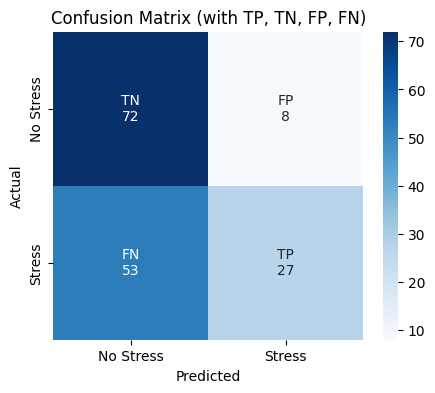

In [40]:
# Extract TN, FP, FN, and TP values from the confusion matrix.
tn, fp, fn, tp = cm.ravel()

# Create text labels for the confusion matrix cells.
labels = [
    [f"TN\n{tn}", f"FP\n{fp}"],
    [f"FN\n{fn}", f"TP\n{tp}"]
]

# Create the figure for the confusion matrix plot.
plt.figure(figsize=(5, 4))

# Plot the confusion matrix with readable TP, TN, FP, and FN annotations.
sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    xticklabels=["No Stress", "Stress"],
    yticklabels=["No Stress", "Stress"]
)

# Add axis labels and a title to explain the plot.
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (with TP, TN, FP, FN)")
plt.show()

**Step 4: Compute evaluation metrics**

In [41]:
# Calculate precision to measure how many predicted stress cases were correct.
precision = precision_score(all_test_labels, all_test_preds)

# Calculate recall to measure how many actual stress cases were detected.
recall = recall_score(all_test_labels, all_test_preds)

# Calculate F1-score as the balance between precision and recall.
f1 = f1_score(all_test_labels, all_test_preds)

# Calculate overall accuracy.
accuracy = accuracy_score(all_test_labels, all_test_preds)

# Calculate ROC AUC using prediction probabilities.
roc_auc = roc_auc_score(all_test_labels, all_test_probs)

# Print all evaluation metrics.
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Precision: 0.7714
Recall: 0.3375
F1-score: 0.4696
Accuracy: 0.6188
ROC AUC: 0.5630


**Step 5: Plot ROC-AUC curve**

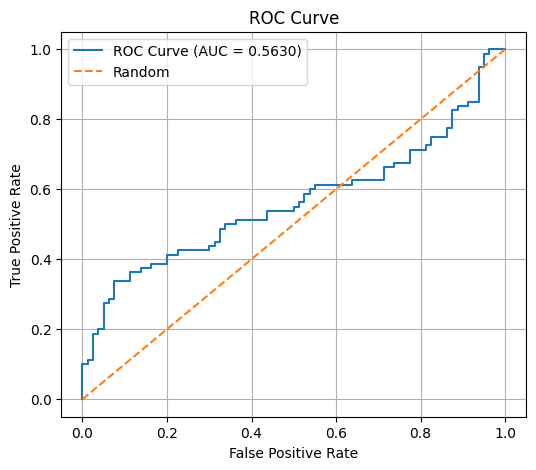

In [42]:
# Compute ROC curve points using the saved test probabilities.
fpr, tpr, _ = roc_curve(all_test_labels, all_test_probs)

# Create the ROC curve figure.
plt.figure(figsize=(6, 5))

# Plot ROC curve using the already computed ROC AUC value.
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")

# Plot the diagonal random-classifier line for comparison.
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

# Add labels, title, legend, and grid to make the plot clear.
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

**Step 6: Save model**

In [43]:
# Save the trained model weights to the Kaggle working directory.
torch.save(model.state_dict(), "/kaggle/working/cnn_lstm_stress_binary.pth")

# Print a message to confirm that the model was saved.
print("Model saved.")

Model saved.
